# PCA Analysis on the Crabs Dataset

In this notebook, I am using **Principal Component Analysis (PCA)** to understand the crab dataset in a simpler way. The dataset has different body measurements of crabs, and I want to see whether PCA can help separate the crabs based on their **species** and **sex**.


## Purpose of this Notebook

The main goal of this notebook is to reduce the number of crab body measurement features and visualize the data more clearly.

In simple words, I am trying to answer:

- Can we use crab body measurements to see patterns between different crab groups?
- Can PCA reduce the original measurements into fewer components while still keeping the important information?
- Can we visualize the crabs better using 2D and 3D PCA plots?

This notebook is written step by step so that the analysis is easy to follow.


## 1. Import Libraries

First, I will import the libraries needed for data handling, visualization, scaling, and PCA.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine learning preprocessing and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ignore unnecessary warning messages to keep the notebook clean
import warnings
warnings.filterwarnings("ignore")

# Display numbers with 3 decimal places for easier reading
pd.set_option("display.precision", 3)

# Set a simple visual style for plots
sns.set_theme(style="whitegrid")


## 2. Load the Dataset

Here, I load the `crabs.csv` file. The notebook expects the CSV file to be in the same folder as this notebook.

The dataset contains crab measurements such as frontal lobe size, rear width, carapace length, maximum width, and body depth.


In [21]:
# Load the dataset
crabs_data = pd.read_csv("crabs.csv")

# Show the first few rows to understand how the data looks
crabs_data.head()

,sp,sex,index,FL,RW,CL,CW,BD
0,B,M,1,8.1,6.7,16.1,19.0,7.0
1,B,M,2,8.8,7.7,18.1,20.8,7.4
2,B,M,3,9.2,7.8,19.0,22.4,7.7
3,B,M,4,9.6,7.9,20.1,23.1,8.2
4,B,M,5,9.8,8.0,20.3,23.0,8.2


## 3. Clean and Rename Columns

Some column names are short, so I rename them to make the notebook easier to understand. I also convert the species and sex codes into full words.


In [22]:
# Rename columns so they are easier to read
crabs_data = crabs_data.rename(columns={
    "sp": "species",
    "FL": "Frontal Lobe",
    "RW": "Rear Width",
    "CL": "Carapace Midline",
    "CW": "Maximum Width",
    "BD": "Body Depth"
})

# Convert short labels into full names
crabs_data["species"] = crabs_data["species"].map({"B": "Blue", "O": "Orange"})
crabs_data["sex"] = crabs_data["sex"].map({"M": "Male", "F": "Female"})

# Create one combined class column using species and sex
# Example: Blue + Male becomes BlueMale
crabs_data["class"] = crabs_data["species"] + crabs_data["sex"]

# Display the cleaned data
crabs_data.head()


,species,sex,index,Frontal Lobe,Rear Width,Carapace Midline,Maximum Width,Body Depth,class
0,Blue,Male,1,8.1,6.7,16.1,19.0,7.0,BlueMale
1,Blue,Male,2,8.8,7.7,18.1,20.8,7.4,BlueMale
2,Blue,Male,3,9.2,7.8,19.0,22.4,7.7,BlueMale
3,Blue,Male,4,9.6,7.9,20.1,23.1,8.2,BlueMale
4,Blue,Male,5,9.8,8.0,20.3,23.0,8.2,BlueMale


After cleaning the data, each crab now belongs to one of four groups: **BlueFemale, BlueMale, OrangeFemale, or OrangeMale**.


## 4. Basic Dataset Check

Before applying PCA, I first check the dataset size, summary statistics, and class distribution. This helps me understand the data before doing any transformation.


In [24]:
# Check the number of rows and columns
print("Dataset shape:", crabs_data.shape)

# Check how many crabs are in each class
print("Number of crabs in each class:")
print(crabs_data["class"].value_counts())


Dataset shape: (200, 9)
Number of crabs in each class:
class
BlueMale        50
BlueFemale      50
OrangeMale      50
OrangeFemale    50
Name: count, dtype: int64


In [25]:
# Summary of all columns
crabs_data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,200,2,Blue,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,200,2,Male,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
index,200.0,NaN,NaN,NaN,25.5,14.467,1.0,13.0,25.5,38.0,50.0
Frontal Lobe,200.0,NaN,NaN,NaN,15.583,3.495,7.2,12.9,15.55,18.05,23.1
Rear Width,200.0,NaN,NaN,NaN,12.738,2.573,6.5,11.0,12.8,14.3,20.2
Carapace Midline,200.0,NaN,NaN,NaN,32.105,7.119,14.7,27.275,32.1,37.225,47.6
Maximum Width,200.0,NaN,NaN,NaN,36.415,7.872,17.1,31.5,36.8,42.0,54.6
Body Depth,200.0,NaN,NaN,NaN,14.03,3.425,6.1,11.4,13.9,16.6,21.6
class,200,4,BlueMale,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset has **200 crab samples**. The target groups are balanced, which is useful because each crab class has a similar number of observations.


## 5. Select Measurement Features

For PCA, I only use the numeric body measurement columns. These are the features that describe each crab physically.


In [28]:
# These are the numeric measurement columns used for PCA
feature_columns = [
    "Frontal Lobe",
    "Rear Width",
    "Carapace Midline",
    "Maximum Width",
    "Body Depth"
]

# Display summary statistics for these measurement columns
crabs_data[feature_columns].describe()


,Frontal Lobe,Rear Width,Carapace Midline,Maximum Width,Body Depth
count,200.000,200.000,200.000,200.000,200.000
mean,15.583,12.738,32.105,36.415,14.030
std,3.495,2.573,7.119,7.872,3.425
min,7.200,6.500,14.700,17.100,6.100
25%,12.900,11.000,27.275,31.500,11.400
50%,15.550,12.800,32.100,36.800,13.900
75%,18.050,14.300,37.225,42.000,16.600
max,23.100,20.200,47.600,54.600,21.600


## 6. Explore the Crab Measurements

Now I will make some simple plots to see how the measurements are distributed and how they differ across the four crab groups.


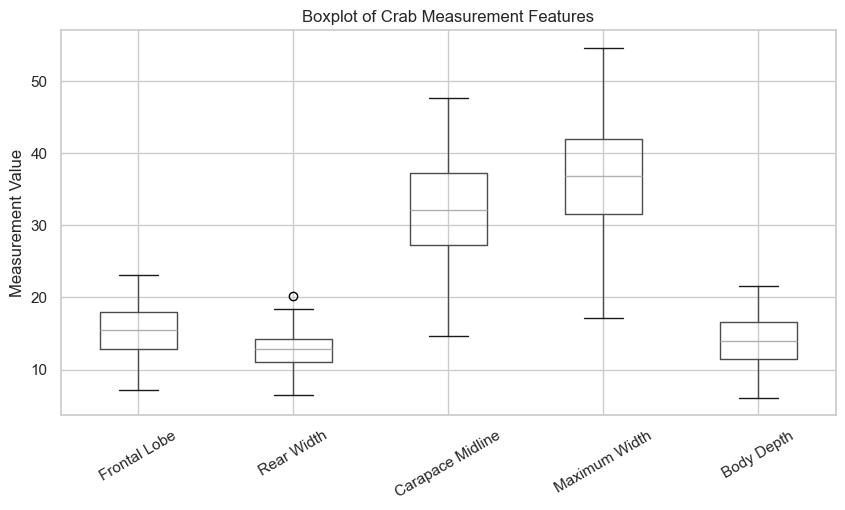

In [29]:
# Boxplot for all measurement features
# This gives a quick idea of spread, median, and possible outliers
plt.figure(figsize=(10, 5))
crabs_data[feature_columns].boxplot()
plt.title("Boxplot of Crab Measurement Features")
plt.ylabel("Measurement Value")
plt.xticks(rotation=30)
plt.show()


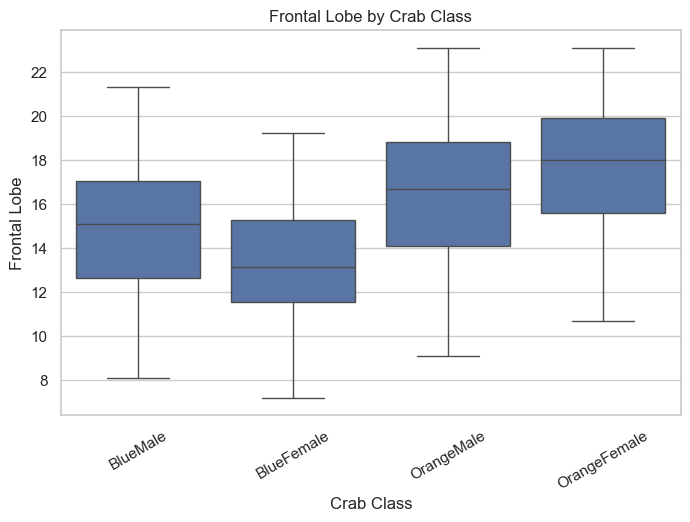

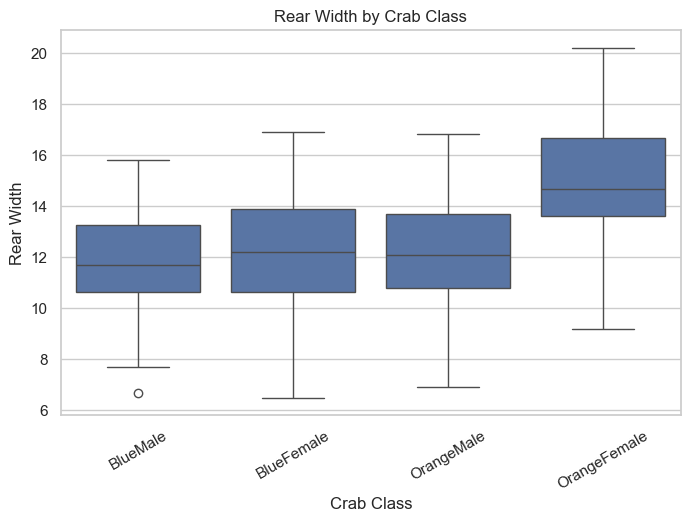

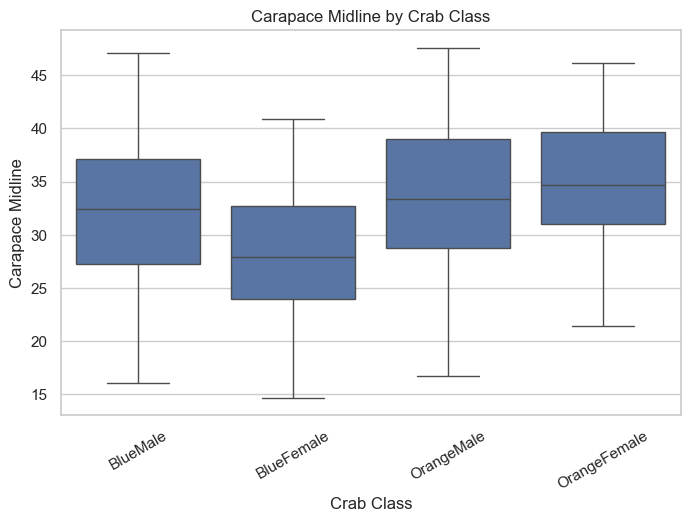

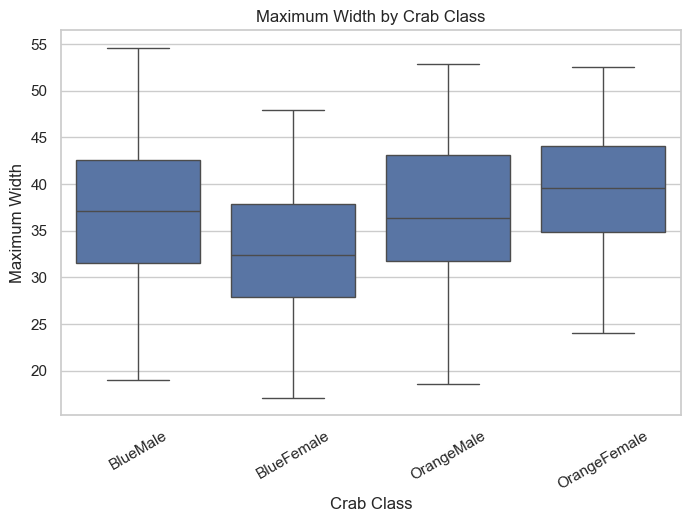

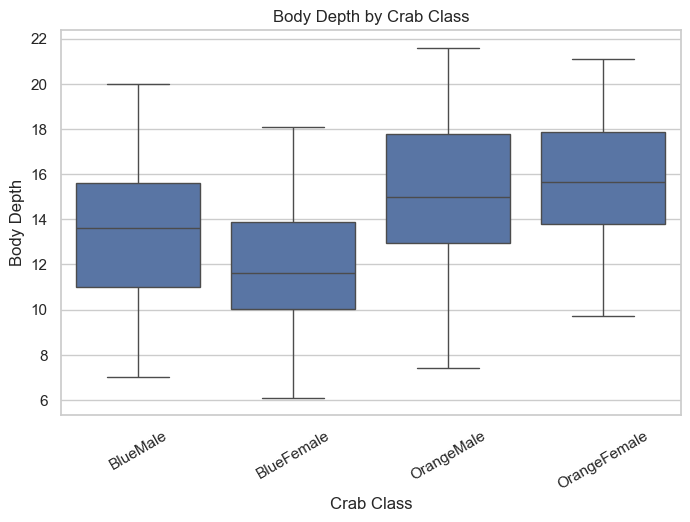

In [30]:
# Boxplots by class for each feature
# These plots help compare crab groups feature by feature
for column in feature_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=crabs_data, x="class", y=column)
    plt.title(f"{column} by Crab Class")
    plt.xlabel("Crab Class")
    plt.ylabel(column)
    plt.xticks(rotation=30)
    plt.show()


The boxplots show that some crab measurements are different across groups, especially between male and female crabs. This suggests that PCA may be able to find useful patterns in the measurements.


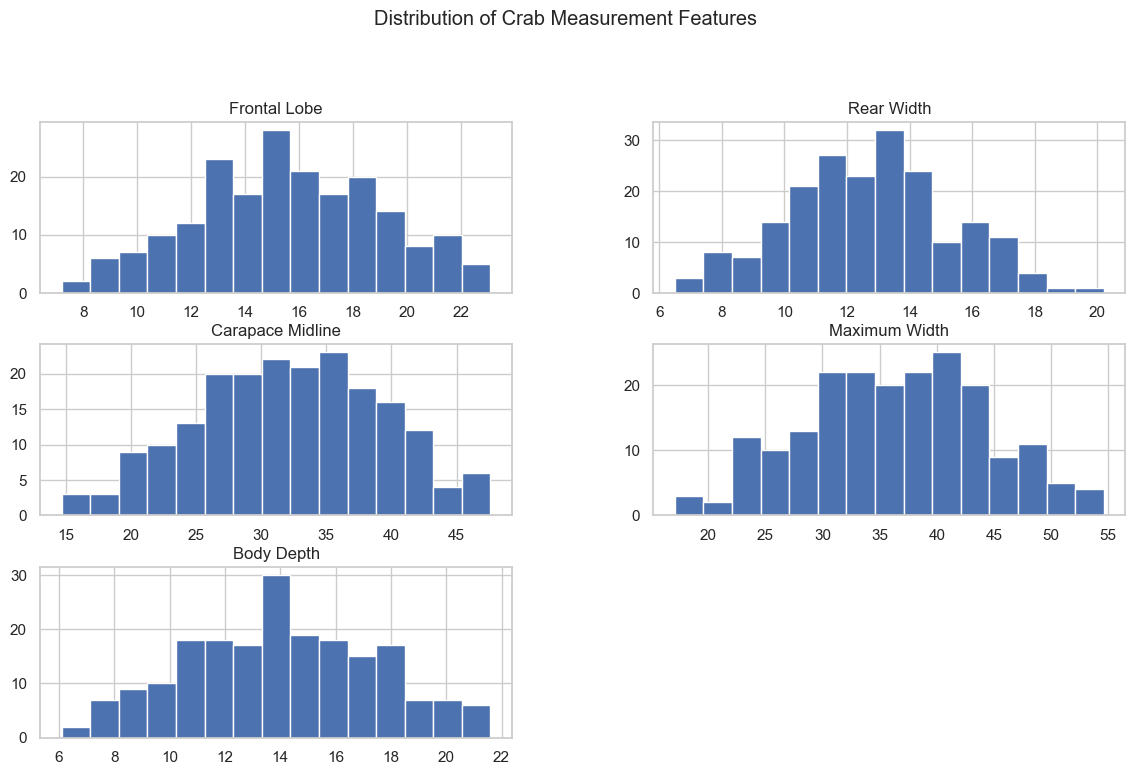

In [31]:
# Histograms for all measurement features
# This shows the distribution of each numeric feature
crabs_data[feature_columns].hist(figsize=(14, 8), bins=15)
plt.suptitle("Distribution of Crab Measurement Features", y=1.02)
plt.show()


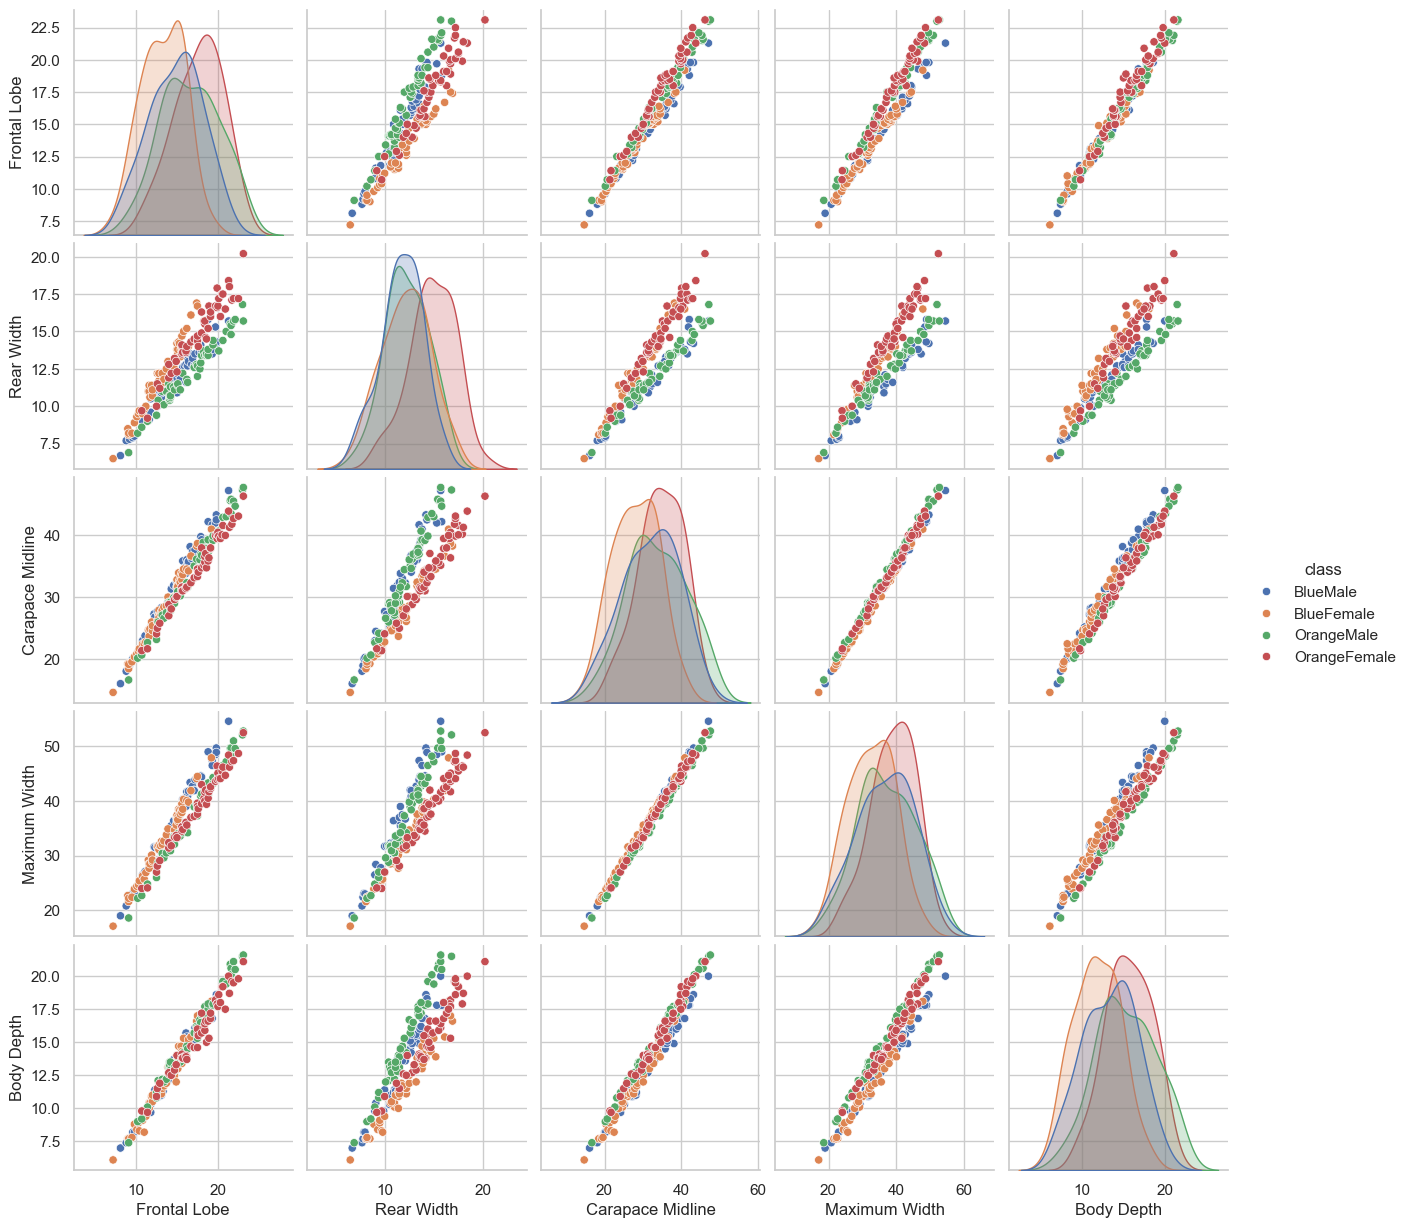

In [32]:
# Pairplot to see relationships between pairs of measurements
# Each color represents a different crab class
sns.pairplot(crabs_data, vars=feature_columns, hue="class")
plt.show()


The pairplot gives a useful first look at the data. Some classes overlap, but there are also visible patterns where certain groups start to separate from each other.


## 7. Why Use PCA?

The dataset has 5 measurement features. Five features are not too many, but it is still hard to visualize all of them together at once.

PCA helps by creating new features called **principal components**. These components combine the original measurements and capture the main patterns in the data.

In simple terms, PCA helps me:

- reduce the number of dimensions,
- remove some repeated information,
- visualize the crabs in 2D or 3D,
- understand which patterns explain most of the variation in the dataset.


## 8. Standardize the Data

PCA is affected by the scale of the features. Since the measurements may have different ranges, I standardize them first.

Standardization changes each feature so that it has:

- mean = 0
- standard deviation = 1

This makes the PCA fair because no feature gets extra importance just because it has larger values.


In [33]:
# Make a copy of the dataset before standardizing
crabs_standardized = crabs_data.copy()

# Create the scaler
scaler = StandardScaler()

# Standardize only the numeric measurement columns
crabs_standardized[feature_columns] = scaler.fit_transform(crabs_data[feature_columns])

# Check the standardized values
crabs_standardized[feature_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
Frontal Lobe,200.0,-7.105e-17,1.003,-2.404,-0.770,-9.465e-03,0.708,2.156
Rear Width,200.0,6.040e-16,1.003,-2.430,-0.677,2.396e-02,0.608,2.907
Carapace Midline,200.0,1.066e-16,1.003,-2.451,-0.680,-7.745e-04,0.721,2.182
Maximum Width,200.0,-4.974e-16,1.003,-2.460,-0.626,4.909e-02,0.711,2.316
Body Depth,200.0,0.000e+00,1.003,-2.321,-0.770,-3.820e-02,0.752,2.216


After standardization, the features are now on the same scale. This means PCA can compare them more fairly.


## 9. Now, lets apply PCA

Now I apply PCA to the standardized measurement features. I first fit PCA using all 5 components so that I can check how much information each component explains.


In [34]:
# Create and fit PCA using all available components
pca = PCA()
pca.fit(crabs_standardized[feature_columns])

# Store explained variance information in a table
pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

# Display PCA summary table
pca_summary


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,9.578e-01,0.958
1,PC2,3.034e-02,0.988
2,PC3,9.327e-03,0.997
3,PC4,2.227e-03,1.000
4,PC5,3.423e-04,1.000


The explained variance ratio tells us how much information each principal component captures. The cumulative variance tells us how much total information is captured as we add more components.


## 10. Scree Plot and Explained Variance Plot

These plots help me decide how many principal components are useful.


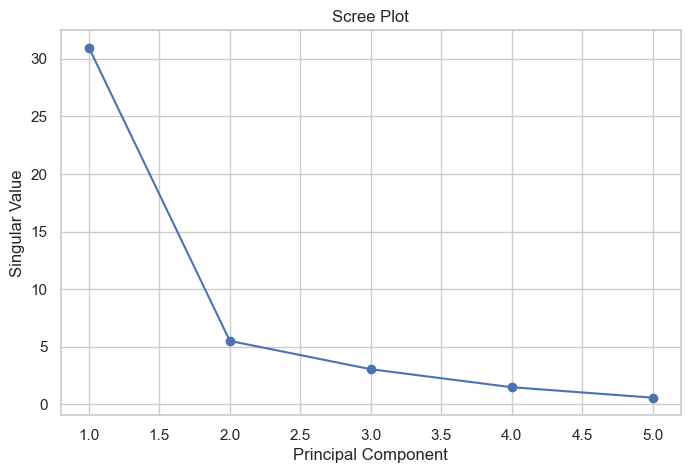

In [35]:
# Scree plot using singular values
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.singular_values_) + 1), pca.singular_values_, marker="o")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Singular Value")
plt.show()


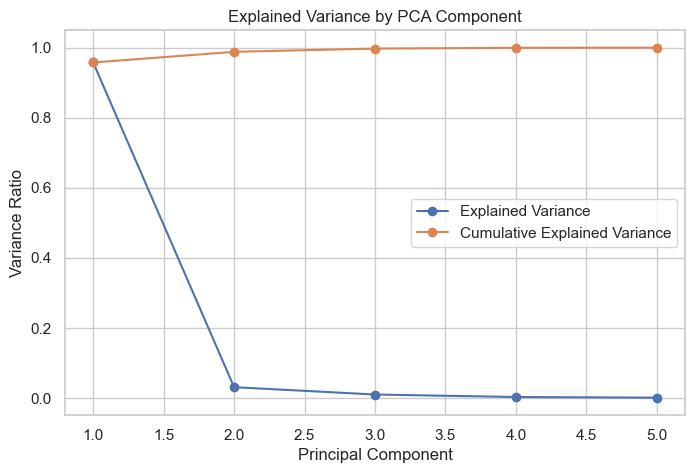

In [36]:
# Plot explained variance and cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
    label="Explained Variance"
)

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o",
    label="Cumulative Explained Variance"
)

plt.title("Explained Variance by PCA Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.legend()
plt.show()


From the explained variance plot, I can see how quickly PCA captures the main information in the dataset. If the first few components explain most of the variance, then PCA is doing a good job of summarizing the original features.


## 11. To understand PCA Component Weights

The heatmap below shows how much each original feature contributes to each principal component.

This is useful because PCA components are not original columns. They are new combinations of the original measurements.


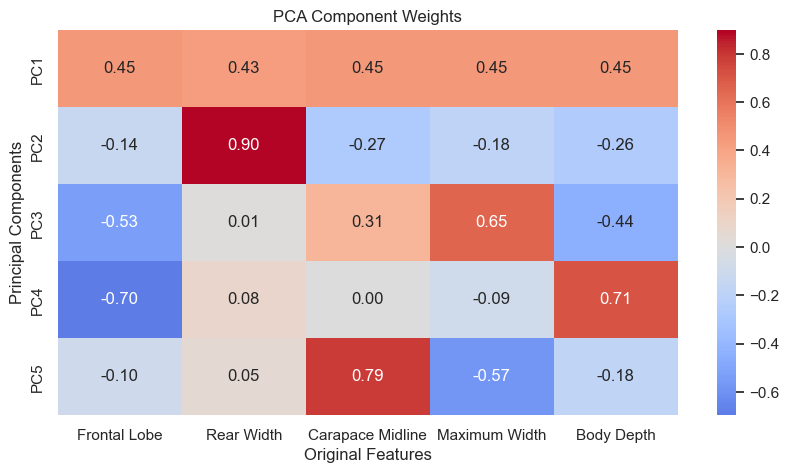

In [39]:
# Heatmap of PCA component weights
plt.figure(figsize=(10, 5))
sns.heatmap(
    pca.components_,
    cmap="coolwarm",
    xticklabels=feature_columns,
    yticklabels=[f"PC{i+1}" for i in range(len(pca.components_))],
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("PCA Component Weights")
plt.xlabel("Original Features")
plt.ylabel("Principal Components")
plt.show()


This heatmap helps explain what PCA is doing internally. A larger positive or negative value means that feature has a stronger effect on that component.


## 12. Lets transform Data into PCA Components

Now I transform the original standardized data into PCA coordinates.

For visualization, I will use the first 3 components: **PC1, PC2, and PC3**.


In [40]:
# Transform the standardized feature data into PCA component values
pca_values = pca.transform(crabs_standardized[feature_columns])

# Add the first three principal components back into the dataframe
crabs_standardized["PC1"] = pca_values[:, 0]
crabs_standardized["PC2"] = pca_values[:, 1]
crabs_standardized["PC3"] = pca_values[:, 2]

# Display the dataset with PCA columns
crabs_standardized.head()


,species,sex,index,Frontal Lobe,Rear Width,Carapace Midline,Maximum Width,Body Depth,class,PC1,PC2,PC3
0,Blue,Male,1,-2.146,-2.352,-2.254,-2.218,-2.058,BlueMale,-4.928,-0.268,-0.122
1,Blue,Male,2,-1.945,-1.963,-1.972,-1.989,-1.941,BlueMale,-4.386,-0.094,-0.039
2,Blue,Male,3,-1.831,-1.924,-1.846,-1.785,-1.853,BlueMale,-4.129,-0.169,0.034
3,Blue,Male,4,-1.716,-1.885,-1.691,-1.696,-1.707,BlueMale,-3.884,-0.246,0.015
4,Blue,Male,5,-1.659,-1.846,-1.662,-1.708,-1.707,BlueMale,-3.834,-0.224,-0.015


Now each crab has three new PCA values. These values summarize the original body measurements and can be used for easier visualization.


## 13. 2D PCA Visualization

First, I plot PC1 and PC2. Each point represents one crab, and the color shows its class.


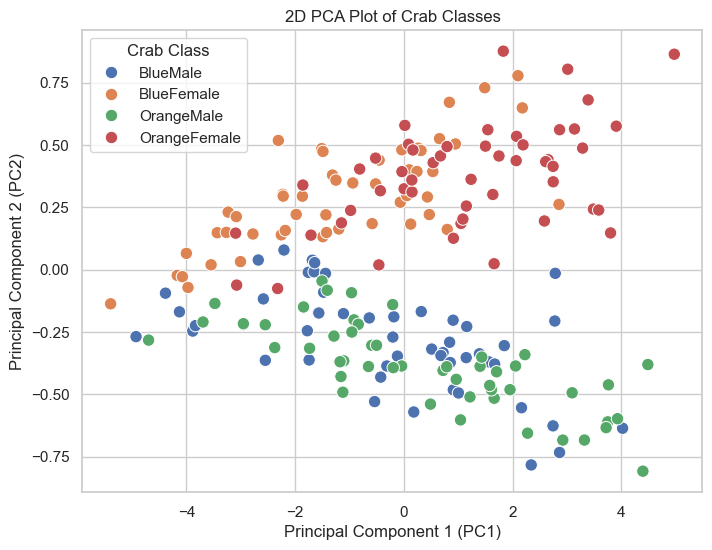

In [42]:
# 2D scatter plot using the first two principal components
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=crabs_standardized,
    x="PC1",
    y="PC2",
    hue="class",
    s=80
)
plt.title("2D PCA Plot of Crab Classes")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title="Crab Class")
plt.show()


The 2D PCA plot gives a simpler view of the crab groups. If points from the same class are close together, it means those crabs have similar body measurement patterns.


## 14. Lets do 3D: 3D PCA Visualization

Now I use PC1, PC2, and PC3 to create a 3D visualization. This gives one more dimension than the 2D plot and can show separation more clearly.


In [43]:
# Interactive 3D PCA plot using Plotly
fig = px.scatter_3d(
    crabs_standardized,
    x="PC1",
    y="PC2",
    z="PC3",
    color="class",
    title="3D PCA Visualization of Crab Classes"
)

fig.show()


In this 3D plot, each point is one crab. Points that are close together have similar body measurements, while points that are far apart are more different.

This plot helps us visually understand whether PCA can separate the crab groups based on their measurements.


## 15. Final Conclusion

In this notebook, I used PCA to simplify and visualize the crab dataset.

The dataset originally had 5 body measurement features. After standardizing the data, I applied PCA to create new principal components that summarize the main patterns in those measurements.

The 2D and 3D PCA plots show that the crab classes have visible patterns and some separation. This means the body measurements contain useful information about the crab groups.

Overall, PCA helped make the dataset easier to understand by reducing multiple measurements into a smaller number of visual components while still keeping the important structure of the data.
